In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('data/g2g_emissions.csv')

In [9]:
display(df.sample(5))
display(df.info())

#df['FOCUS_TYPE'].value_counts()
df = df.drop( columns = ('FOCUS_TYPE'))

df['CO2_KG'] = df['CO2_TONS'] * 1000
df = df.drop(columns = 'CO2_TONS')

,LEVEL,AREA,FOCUS_TYPE,YEAR,MONTH,MARKET_SEGMENT,FLIGHT_TYPE,FLIGHT_PHASE,NB_FLIGHTS,CO2_TONS,NOX_KG,SOX_KG
495783,STATE,BG,AREA FOCUS,2024,8,business,A,taxi-in,299,19.0,13.56,4.86
273607,STATE,RS,AREA FOCUS,2024,9,other,O,climb,9018,113.6,926.41,30.03
180518,STATE,TR,AREA FOCUS,2022,4,other,O,taxi-out,2964,2.0,1.91,0.55
446097,STATE,NL,AREA FOCUS,2023,4,mainline,A,taxi-out,8122,2.1,0.60,0.55
426817,STATE,MA,AREA FOCUS,2022,10,lowcost,I,taxi-in,170,4.2,5.77,1.12


<class 'pandas.DataFrame'>
RangeIndex: 511627 entries, 0 to 511626
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LEVEL           511627 non-null  str    
 1   AREA            511627 non-null  str    
 2   FOCUS_TYPE      511627 non-null  str    
 3   YEAR            511627 non-null  int64  
 4   MONTH           511627 non-null  int64  
 5   MARKET_SEGMENT  511627 non-null  str    
 6   FLIGHT_TYPE     511627 non-null  str    
 7   FLIGHT_PHASE    511627 non-null  str    
 8   NB_FLIGHTS      511627 non-null  int64  
 9   CO2_TONS        511627 non-null  float64
 10  NOX_KG          511627 non-null  float64
 11  SOX_KG          511627 non-null  float64
dtypes: float64(3), int64(3), str(6)
memory usage: 46.8 MB


None

In [10]:
df.duplicated().value_counts()
df = df.drop_duplicates()

In [11]:
df_state = df[df['LEVEL'] == 'STATE']
df_network = df[df['LEVEL'] == 'NETWORK']

df_state.to_csv('data/clean/emission_state_clean.csv', index=False)
df_network.to_csv('data/clean/emission_network_clean.csv', index=False)

---
---

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

emission_net = pd.read_csv("data/clean/emission_network_clean.csv")
emission_state = pd.read_csv("data/clean/emission_state_clean.csv")

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# State code to name mapping for readability
state_names = {
    'GB': 'United Kingdom', 'FR': 'France', 'TR': 'Türkiye', 'DE': 'Germany',
    'ES': 'Spain', 'IT': 'Italy', 'GR': 'Greece', 'RO': 'Romania',
    'PL': 'Poland', 'PT - Lisbon FIR': 'Portugal', 'NO': 'Norway',
    'NL': 'Netherlands', 'SE': 'Sweden', 'CH': 'Switzerland', 'BE': 'Belgium'
}

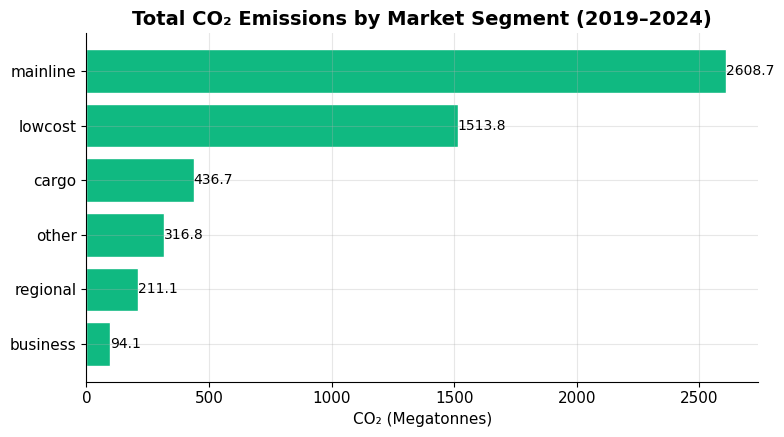

In [13]:
# ============================================================
# EM1 – Total CO₂ emissions by market segment
# ============================================================
co2_seg = (emission_net
           .groupby("MARKET_SEGMENT")["CO2_KG"]
           .sum()
           .sort_values(ascending=True)
           .reset_index())
co2_seg["CO2_MT"] = co2_seg["CO2_KG"] / 1e9

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(co2_seg["MARKET_SEGMENT"], co2_seg["CO2_MT"],
               color="#10B981", edgecolor="white")
ax.set_title("Total CO₂ Emissions by Market Segment (2019–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("CO₂ (Megatonnes)")
for bar in bars:
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}", va="center", fontsize=10)
plt.tight_layout()
plt.show()

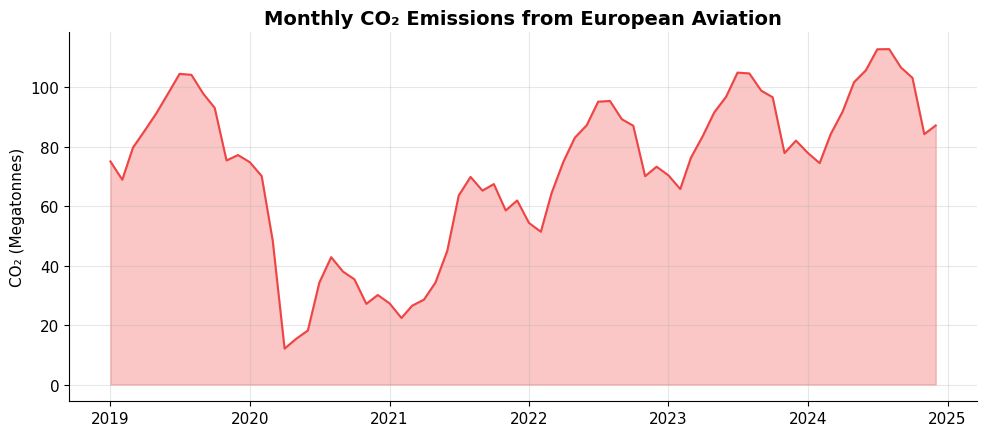

In [14]:
# ============================================================
# EM2 – Monthly CO₂ trend over time (network level)
# ============================================================
co2_monthly = (emission_net
               .groupby(["YEAR", "MONTH"])["CO2_KG"]
               .sum()
               .reset_index())
co2_monthly["DATE"] = pd.to_datetime(
    co2_monthly["YEAR"].astype(str) + "-" + co2_monthly["MONTH"].astype(str) + "-01"
)
co2_monthly = co2_monthly.sort_values("DATE")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(co2_monthly["DATE"], co2_monthly["CO2_KG"] / 1e9,
                alpha=0.3, color="#EF4444")
ax.plot(co2_monthly["DATE"], co2_monthly["CO2_KG"] / 1e9,
        color="#EF4444", linewidth=1.5)
ax.set_title("Monthly CO₂ Emissions from European Aviation",
             fontsize=14, fontweight="bold")
ax.set_ylabel("CO₂ (Megatonnes)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

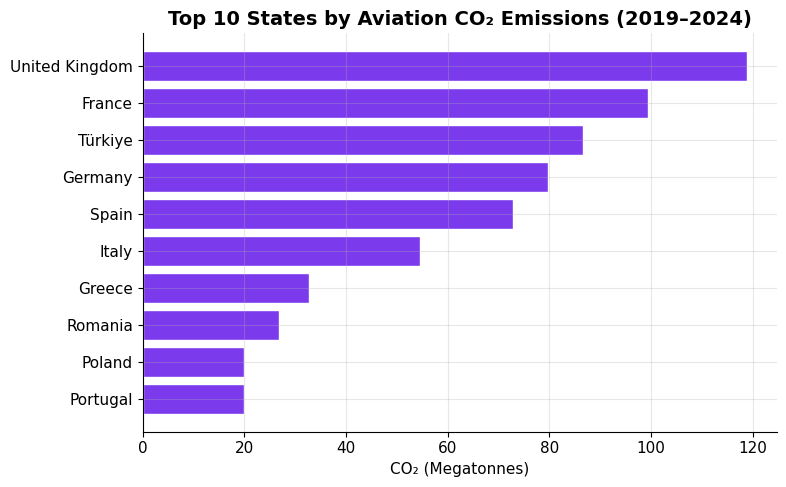

In [15]:
# ============================================================
# EM3 – Top 10 states by total CO₂ emissions
# ============================================================
co2_state = (emission_state
             .groupby("AREA")["CO2_KG"]
             .sum()
             .nlargest(10)
             .sort_values()
             .reset_index())
co2_state["label"] = co2_state["AREA"].map(state_names).fillna(co2_state["AREA"])
co2_state["CO2_MT"] = co2_state["CO2_KG"] / 1e9

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(co2_state["label"], co2_state["CO2_MT"], color="#7C3AED", edgecolor="white")
ax.set_title("Top 10 States by Aviation CO₂ Emissions (2019–2024)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("CO₂ (Megatonnes)")
plt.tight_layout()
plt.show()

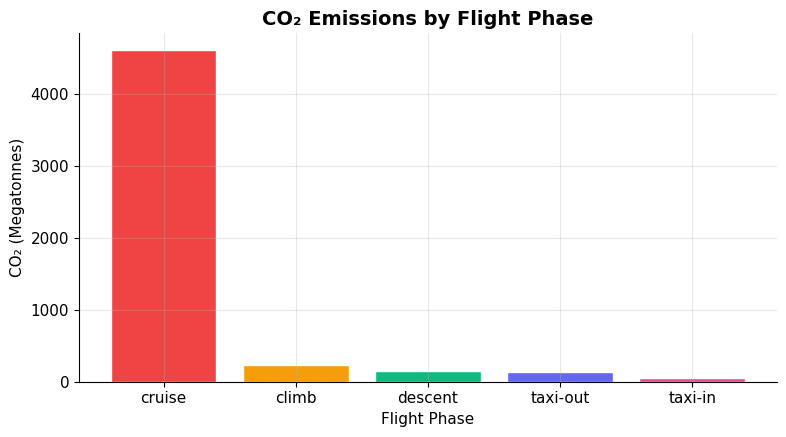

In [16]:
# ============================================================
# EM4 – CO₂ emissions by flight phase (network level)
# ============================================================
co2_phase = (emission_net
             .groupby("FLIGHT_PHASE")["CO2_KG"]
             .sum()
             .sort_values(ascending=False)
             .reset_index())
co2_phase["CO2_MT"] = co2_phase["CO2_KG"] / 1e9

fig, ax = plt.subplots(figsize=(8, 4.5))
colors_phase = ["#EF4444", "#F59E0B", "#10B981", "#6366F1", "#EC4899"]
ax.bar(co2_phase["FLIGHT_PHASE"], co2_phase["CO2_MT"],
       color=colors_phase[:len(co2_phase)], edgecolor="white")
ax.set_title("CO₂ Emissions by Flight Phase",
             fontsize=14, fontweight="bold")
ax.set_ylabel("CO₂ (Megatonnes)")
ax.set_xlabel("Flight Phase")
plt.tight_layout()
plt.show()

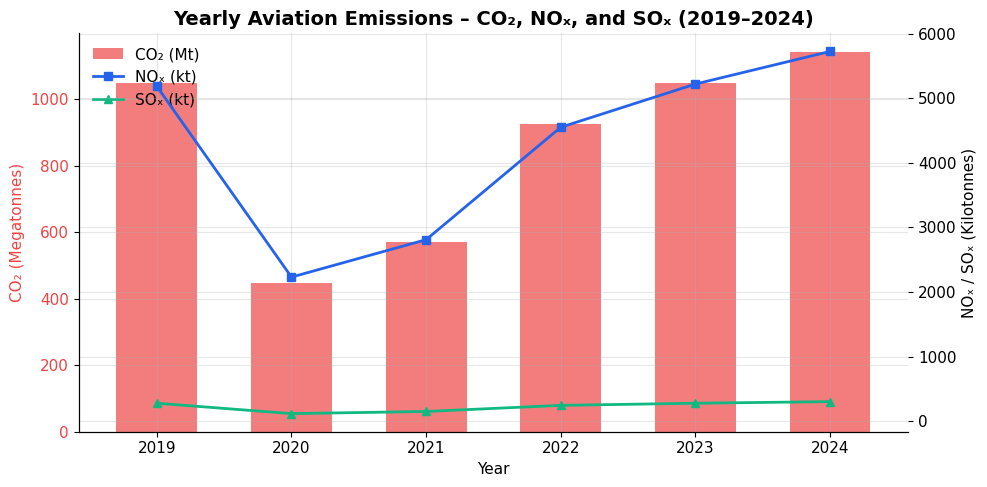

In [17]:
# ============================================================
# EM5 – Yearly CO₂ trend by pollutant type (CO₂, NOx, SOx)
# ============================================================
yearly_poll = (emission_net
               .groupby("YEAR")[["CO2_KG", "NOX_KG", "SOX_KG"]]
               .sum()
               .reset_index())

fig, ax1 = plt.subplots(figsize=(10, 5))

color_co2 = "#EF4444"
ax1.bar(yearly_poll["YEAR"], yearly_poll["CO2_KG"] / 1e9,
        color=color_co2, alpha=0.7, label="CO₂ (Mt)", width=0.6)
ax1.set_ylabel("CO₂ (Megatonnes)", color=color_co2)
ax1.tick_params(axis="y", labelcolor=color_co2)
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(yearly_poll["YEAR"], yearly_poll["NOX_KG"] / 1e6, marker="s",
         color="#2563EB", linewidth=2, label="NOₓ (kt)")
ax2.plot(yearly_poll["YEAR"], yearly_poll["SOX_KG"] / 1e6, marker="^",
         color="#10B981", linewidth=2, label="SOₓ (kt)")
ax2.set_ylabel("NOₓ / SOₓ (Kilotonnes)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

ax1.set_title("Yearly Aviation Emissions – CO₂, NOₓ, and SOₓ (2019–2024)",
              fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()